nn.Conv1d Example (sequence / signal)

1. nn.Conv1d

Used for 1D signals:

Audio signals
ECG signals
Time series
Sensor data

In [5]:
import torch
import torch.nn as nn

conv1d = nn.Conv1d(
    in_channels=1,
    out_channels=2,
    kernel_size=3
)

x = torch.tensor([[
    [1., 2., 3., 4., 5.]
]])  # shape = (1,1,5)

print("Input shape:", x.shape)

y = conv1d(x)

print("Output shape:", y.shape)
print(y)

Input shape: torch.Size([1, 1, 5])
Output shape: torch.Size([1, 2, 3])
tensor([[[-0.3777, -0.5886, -0.7994],
         [-1.2760, -1.6929, -2.1099]]], grad_fn=<ConvolutionBackward0>)


nn.convd used for images 

In [8]:
import torch
import torch.nn as nn

conv2d = nn.Conv2d(
    in_channels=1,
    out_channels=2,
    kernel_size=3
)

x = torch.randn(1, 1, 5, 5)

print("Input shape:", x.shape)

y = conv2d(x)

print("Output shape:", y.shape)

Input shape: torch.Size([1, 1, 5, 5])
Output shape: torch.Size([1, 2, 3, 3])


nn.conv3d used for videos medical scans ,3d data
Examples:

MRI scan
CT scan
Video classification


In [ ]:
import torch
import torch.nn as nn

conv3d = nn.Conv3d(
    in_channels=1,
    out_channels=2,
    kernel_size=3
)

x = torch.randn(1, 1, 5, 5, 5)

print("Input shape:", x.shape)

y = conv3d(x)

print("Output shape:", y.shape)

Input:

(batch_size, channels, depth, height, width)

(1,1,5,5,5)

Kernel:

3 x 3 x 3

Output:

(1,2,3,3,3)

Visualization:

A video with 5 frames:

Frame 1
Frame 2
Frame 3
Frame 4
Frame 5

The 3D kernel moves through:

time (depth)
height
width

simultaneously.

| Layer    | Input Shape   | Example                 |
| -------- | ------------- | ----------------------- |
| `Conv1d` | `(N,C,L)`     | ECG, audio, time series |
| `Conv2d` | `(N,C,H,W)`   | Images                  |
| `Conv3d` | `(N,C,D,H,W)` | Videos, MRI, CT scans   |


nn.ConvTranspose1d
It is used to increase the size (length) of a 1D signal.

Input length = 100
Conv1d
Output length = 50

Input length = 50
ConvTranspose1d
Output length = 100

This is common in:

Autoencoders
Generative models
Audio generation
Signal processing
U-Net architectures

| Parameter        | Description                |
| ---------------- | -------------------------- |
| `in_channels`    | Number of input channels   |
| `out_channels`   | Number of output channels  |
| `kernel_size`    | Size of the filter         |
| `stride`         | Controls upsampling factor |
| `padding`        | Padding applied            |
| `output_padding` | Extra size adjustment      |


In [2]:
import torch 
import torch.nn as nn 

x = torch.randn(1,1,10)

layer = nn.ConvTranspose1d(
    in_channels=1,
    out_channels=2,
    kernel_size=4,
    stride=2
)

y = layer(x)

print(x.shape)
print(y.shape)

torch.Size([1, 1, 10])
torch.Size([1, 2, 22])


Explanation:

Batch size = 1
Input channels = 2
Input length = 10

After transposed convolution:

Output channels = 2
Length becomes 22

exemple :
Input:
[o1 o2 o3 o4]

ConvTranspose1d

Output:
[1 2 3 4 5 6]

2.nn.ConvTranspose2d

nn.ConvTranspose2d is a 2D transposed convolution layer used to increase the height and width of feature maps.

It is often called deconvolution, but technically it is not a true deconvolution.

A normal convolution (nn.Conv2d) usually reduces the spatial dimensions:
Input Image: 64 × 64
      ↓
Conv2d (stride=2)
      ↓
Output: 32 × 32

To recover the original size, we can use:
Input: 32 × 32
      ↓
ConvTranspose2d (stride=2)
      ↓
Output: 64 × 64

This is commonly used in:

Autoencoders
U-Net
Image Segmentation
GANs (Generative Adversarial Networks)
Super-Resolution Networks

In [4]:
import torch 
import torch.nn as nn 

x = torch.randn(1,3,24,24)

layer2 = nn.ConvTranspose2d(
    in_channels=3,
    out_channels=4,
    kernel_size=4,
    stride=4,
    padding=0,
    output_padding=0,
)

y = layer2(x)

print(x.shape)
print(y.shape)

torch.Size([1, 3, 24, 24])
torch.Size([1, 4, 96, 96])


let's create autoencoder 

In [11]:

encoder = nn.Conv2d(
    3,
    32,
    kernel_size=4,
    stride=2,
    padding=1
)
#input 3*128*128
#output 32*64*64

decoder = nn.ConvTranspose2d(
    32,
    3,
    kernel_size=4,
    stride=2,
    padding=1
)

#output 3*128*12
x = torch.randn(3,3,128,128)
y = encoder(x)
z = decoder(y)

print(x.shape)
print(y.shape)
print(z.shape)

torch.Size([3, 3, 128, 128])
torch.Size([3, 32, 64, 64])
torch.Size([3, 3, 128, 128])


Typical GAN Example
Generator networks often use several transposed convolutions:


In [12]:
nn.Sequential(
    nn.ConvTranspose2d(100, 512, 4, 1, 0),
    nn.ReLU(),

    nn.ConvTranspose2d(512, 256, 4, 2, 1),
    nn.ReLU(),

    nn.ConvTranspose2d(256, 128, 4, 2, 1),
    nn.ReLU(),

    nn.ConvTranspose2d(128, 3, 4, 2, 1),
    nn.Tanh()
)

Sequential(
  (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1))
  (1): ReLU()
  (2): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (3): ReLU()
  (4): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (5): ReLU()
  (6): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (7): Tanh()
)

3.nn.ConvTranspose3d
It is used to increase the size of 3D data, such as:

Medical scans (CT, MRI)
3D objects
Volumetric data
Videos (time × height × width)
forme :
    (batch_size, channels, depth, height, width)

    where:

batch_size = number of samples
channels = number of feature maps
depth = third spatial dimension (or time for videos)
height = image height
width = image width

Conv3d often reduces dimensions:
Input Volume
16 × 64 × 64
      ↓
Conv3d(stride=2)
      ↓
8 × 32 × 32

To reconstruct the original volume:
8 × 32 × 32
      ↓
ConvTranspose3d(stride=2)
      ↓
16 × 64 × 64


In [13]:
import torch 
import torch.nn as nn 

x = torch.randn(1,16,8,32,32)

layer3 = nn.ConvTranspose3d(
    in_channels=16,
    out_channels=8,
    kernel_size=4,
    stride=2,
    padding=1
)


y = layer3(x)
print(x.shape)
print(y.shape)

torch.Size([1, 16, 8, 32, 32])
torch.Size([1, 8, 16, 64, 64])


Typical Autoencoder Decoder

In [ ]:
decoder = nn.Sequential(
    nn.ConvTranspose3d(
        128, 64,
        kernel_size=4,
        stride=2,
        padding=1
    ),
    nn.ReLU(),

    nn.ConvTranspose3d(
        64, 32,
        kernel_size=4,
        stride=2,
        padding=1
    ),
    nn.ReLU(),

    nn.ConvTranspose3d(
        32, 1,
        kernel_size=4,
        stride=2,
        padding=1
    )
)

The encoder compresses a 128×128 RGB image into a latent representation, and the decoder reconstructs it using nn.ConvTranspose2d.

In [14]:
import torch
import torch.nn as nn

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ======================
        # Encoder
        # ======================
        self.encoder = nn.Sequential(

            # 128x128 -> 64x64
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 64x64 -> 32x32
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 32x32 -> 16x16
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 16x16 -> 8x8
            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU()
        )

        # ======================
        # Decoder
        # ======================
        self.decoder = nn.Sequential(

            # 8x8 -> 16x16
            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(
                64,
                32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 64x64 -> 128x128
            nn.ConvTranspose2d(
                32,
                3,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction


model = AutoEncoder()
print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Sigmoid()
  )
)


In [15]:
x = torch.randn(8, 3, 128, 128)
y = model(x)
print(y.shape)

torch.Size([8, 3, 128, 128])


here  the trainng loop you can lake a dataset of image and see the resultats 

In [ ]:
from PIL import Image
from torchvision.transforms import v2

img = Image.open("images/dress1.jpg")
print(type(img))
transform = v2.ToImage()
img_tensor = transform(img)
print(type(img_tensor))

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoEncoder().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 20

for epoch in range(epochs):

    running_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

NameError: name 'train_loader' is not defined

i’re very close — my issue is that i only load one image manually, but my training loop expects a DataLoader (train_loader) that already gives batches of images.

In [17]:
import torch
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
from torch.utils.data import DataLoader

# -------------------------
# 1. Transform
# -------------------------
transform = v2.Compose([
    v2.Resize((128, 128)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

# -------------------------
# 2. Dataset
# -------------------------
dataset = ImageFolder(root="images", transform=transform)

# -------------------------
# 3. DataLoader
# -------------------------
train_loader = DataLoader(
    dataset,
    batch_size=1,   # better than 1
    shuffle=True
)

# -------------------------
# 4. Device
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# 5. Model
# -------------------------
model = AutoEncoder().to(device)

# -------------------------
# 6. Loss + Optimizer
# -------------------------
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# -------------------------
# 7. Training loop
# -------------------------
epochs = 20

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        # forward
        outputs = model(images)

        # loss
        loss = criterion(outputs, images)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

FileNotFoundError: Couldn't find any class folder in images.

❌ ERROR 1: ImageFolder requirement (MAIN PROBLEM)
FileNotFoundError: Couldn't find any class folder in images.
🔴 Why this happens

ImageFolder ONLY works if your dataset looks like this:

images/
   class1/
      img1.jpg
      img2.jpg
   class2/
      img1.jpg

But you said:

"there is no class in my data"

👉 So ImageFolder is WRONG for you.

THE RIGHT CODE FOR MY CASE

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from PIL import Image
import os
import matplotlib.pyplot as plt

#Transform
transform = v2.Compose([
    v2.Resize((128, 128)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

#Custom Dataset (IMPORTANT FIX)

class MyDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = [
            os.path.join(root, f)
            for f in os.listdir(root)
            if f.endswith((".jpg", ".png", ".jpeg"))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img  # IMPORTANT: no label
    

#Dataset + DataLoader
dataset = MyDataset(root="images", transform=transform)

train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)


#foction to see the reconstute image 

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoEncoder().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images in train_loader:   # <-- ONLY images, no labels

        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/20] Loss: 0.1460
Epoch [2/20] Loss: 0.1451
Epoch [3/20] Loss: 0.1432
Epoch [4/20] Loss: 0.1382
Epoch [5/20] Loss: 0.1233
Epoch [6/20] Loss: 0.0985
Epoch [7/20] Loss: 0.1026
Epoch [8/20] Loss: 0.0953
Epoch [9/20] Loss: 0.0814
Epoch [10/20] Loss: 0.0724
Epoch [11/20] Loss: 0.0719
Epoch [12/20] Loss: 0.0668
Epoch [13/20] Loss: 0.0588
Epoch [14/20] Loss: 0.0562
Epoch [15/20] Loss: 0.0543
Epoch [16/20] Loss: 0.0474
Epoch [17/20] Loss: 0.0439
Epoch [18/20] Loss: 0.0438
Epoch [19/20] Loss: 0.0380
Epoch [20/20] Loss: 0.0387


| Task                    | Use            |
| ----------------------- | -------------- |
| Classification dataset  | ImageFolder    |
| AutoEncoder / no labels | Custom Dataset |
| Single image testing    | Image.open     |
| Batch training          | DataLoader     |


Epoch [1/200] Loss: 0.1344
Epoch [2/200] Loss: 0.1340
Epoch [3/200] Loss: 0.1333
Epoch [4/200] Loss: 0.1311
Epoch [5/200] Loss: 0.1245
Epoch [6/200] Loss: 0.1082
Epoch [7/200] Loss: 0.0875
Epoch [8/200] Loss: 0.0918
Epoch [9/200] Loss: 0.0858
Epoch [10/200] Loss: 0.0740
Epoch [11/200] Loss: 0.0679
Epoch [12/200] Loss: 0.0700
Epoch [13/200] Loss: 0.0682
Epoch [14/200] Loss: 0.0624
Epoch [15/200] Loss: 0.0603
Epoch [16/200] Loss: 0.0604
Epoch [17/200] Loss: 0.0565
Epoch [18/200] Loss: 0.0520
Epoch [19/200] Loss: 0.0518
Epoch [20/200] Loss: 0.0487
Epoch [21/200] Loss: 0.0437
Epoch [22/200] Loss: 0.0429
Epoch [23/200] Loss: 0.0410
Epoch [24/200] Loss: 0.0383
Epoch [25/200] Loss: 0.0387
Epoch [26/200] Loss: 0.0358
Epoch [27/200] Loss: 0.0357
Epoch [28/200] Loss: 0.0345
Epoch [29/200] Loss: 0.0347
Epoch [30/200] Loss: 0.0341
Epoch [31/200] Loss: 0.0332
Epoch [32/200] Loss: 0.0331
Epoch [33/200] Loss: 0.0331
Epoch [34/200] Loss: 0.0329
Epoch [35/200] Loss: 0.0319
Epoch [36/200] Loss: 0.0334
E

IndexError: index 4 is out of bounds for dimension 0 with size 4

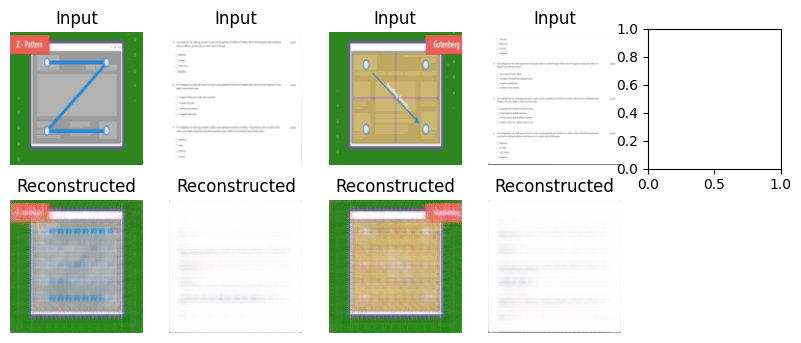

In [22]:

# =========================
# TRAINING SETUP
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoEncoder().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 200

# =========================
# TRAIN LOOP
# =========================
for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images in train_loader:
        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")


# =========================
# VISUALIZATION FUNCTION
# =========================
def show_reconstruction(model, dataloader, device, n=6):
    model.eval()

    images = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)

    images = images.cpu()
    outputs = outputs.cpu()

    plt.figure(figsize=(12, 4))

    for i in range(n):
        # Input
        plt.subplot(2, n, i + 1)
        plt.imshow(torch.clamp(images[i].permute(1, 2, 0), 0, 1))
        plt.title("Input")
        plt.axis("off")

        # Reconstructed
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(torch.clamp(outputs[i].permute(1, 2, 0), 0, 1))
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# SHOW RESULTS
# =========================
show_reconstruction(model, train_loader, device)

Why Use an Autoencoder?

Applications include:

Image Compression
    Store latent vectors instead of full images.
Denoising Autoencoder
    Input noisy image.
Output clean image.
    Anomaly Detection
Train on normal images only.
    High reconstruction error indicates anomalies.
Feature Extraction
    Use the encoder output as learned features.
Pretraining
    learn useful image representations before classification.

The core idea is:

Image
   ↓
Encoder
   ↓
Compressed Representation (Latent Space)
   ↓
Decoder
   ↓
Reconstructed Image

The network learns to keep only the most important information needed to

-----------------------------------------------------------------------

nn.LazyConv1d 
is a 1D convolution layer where you do NOT need to manually specify in_channels.

Instead, PyTorch infers it automatically the first time you pass data through the layer.

PyTorch waits (“is lazy”) until it sees real input data to determine:
number of input channels
then builds the internal wei

In [23]:
import torch 
import torch.nn as nn 

conv = nn.LazyConv1d(out_channels=4,kernel_size=3)

x = torch.randn(2,5,100)# (batch=2, channels=5, length=100)
y = conv(x)
print("Output shape:", y.shape)

Output shape: torch.Size([2, 4, 98])


✅ Advantages
No need to manually compute input channels
Useful when building models dynamically
Good for quick prototyping
Helpful in large models where input shape is not known in advance
❌ Disadvantages
Harder to debug sometimes
Less explicit (can hide architecture details)
Not always recommended in production

LazyConv2d
s a 2D convolution layer in PyTorch that does NOT require you to specify in_channels.

Instead, PyTorch automatically determines the number of input channels the first time you pass data through it.

In [24]:
import torch
import torch.nn as nn 

conv2lazy = nn.LazyConv2d(out_channels=8,kernel_size=3)
x = torch.randn(1,3,64,64)# (batch, channels, height, width)
y = conv2lazy(x)
print("outputs shpas ", y.shape)

outputs shpas  torch.Size([1, 8, 62, 62])


it the same for nn.LazyConv3d

-------------------------------------------------------------------

nn.Unfold

nn.Unfold extracts small sliding patches (blocks) from an image and converts them into columns.

In [5]:
import torch
import torch.nn as nn

x = torch.arange(1,17).float().reshape(1,1,4,4)

unfold = nn.Unfold(kernel_size=2)

y = unfold(x)
print(x,"\n")
print(y,"\n")
print(y.shape,"\n")

tensor([[[[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]]) 

tensor([[[ 1.,  2.,  3.,  5.,  6.,  7.,  9., 10., 11.],
         [ 2.,  3.,  4.,  6.,  7.,  8., 10., 11., 12.],
         [ 5.,  6.,  7.,  9., 10., 11., 13., 14., 15.],
         [ 6.,  7.,  8., 10., 11., 12., 14., 15., 16.]]]) 

torch.Size([1, 4, 9]) 



Fold places them baack into their original positions 

performe the oppostion operation of unfolld 
it takes many patches and reconstructs the image 

In [6]:
import torch
import torch.nn as nn

x = torch.arange(1,17).float().reshape(1,1,4,4)

unfold = nn.Unfold(kernel_size=2)
patches = unfold(x)

fold = nn.Fold(
    output_size=(4,4),
    kernel_size=2
)

reconstructed = fold(patches)

print(x,"\n")
print(patches,"\n")
print(reconstructed)

tensor([[[[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]]) 

tensor([[[ 1.,  2.,  3.,  5.,  6.,  7.,  9., 10., 11.],
         [ 2.,  3.,  4.,  6.,  7.,  8., 10., 11., 12.],
         [ 5.,  6.,  7.,  9., 10., 11., 13., 14., 15.],
         [ 6.,  7.,  8., 10., 11., 12., 14., 15., 16.]]]) 

tensor([[[[ 1.,  4.,  6.,  4.],
          [10., 24., 28., 16.],
          [18., 40., 44., 24.],
          [13., 28., 30., 16.]]]])


loookkkkk fold not the reverse od unfold 
fold(unfold(x)) == x    (not true )
exempls 
1   2   3   4
5   6   7   8
9  10  11  12
13 14  15  16

The patches are:
    P1 = [1,2,5,6]
    P2 = [2,3,6,7]
    P3 = [3,4,7,8]

    P4 = [5,6,9,10]
    P5 = [6,7,10,11]
    P6 = [7,8,11,12]

    P7 = [9,10,13,14]
    P8 = [10,11,14,15]
    P9 = [11,12,15,16]

notice something:
    6 appears in:
    P1
    P2
    P4
    P5

The same pixel belongs to multiple patches.

When Fold places patches back, it adds overlapping values.
For example, pixel (1,1) (value 6):
P1 contributes 6
P2 contributes 6
P4 contributes 6
P5 contributes 6

So Fold computes:6 + 6 + 6 + 6 = 24

instead of 6 
Result

tensor([[[[ 1.,  4.,  6.,  4.],
          [10., 24., 28., 16.],
          [18., 40., 44., 24.],
          [13., 28., 30., 16.]]]])

6  -> 24
10 -> 40
11 -> 44
because they appear in several overlapping patches.

Rule to remember
    Unfold = extract patches
    Fold = put patches back and SUM overlaps